# Evaluation of Generation and Single Choice Tasks

This notebook loads the results of the previous tasks for evaluation

In [ ]:
!pip install s3fs

In [ ]:
import pandas as pd
from google.colab import userdata
import seaborn as sns
import matplotlib.pyplot as plt

In [34]:
style = {
    "alpha": 0.8,
}
sns.set_theme(style="whitegrid")

In [35]:
storage_options={
  "key": userdata.get('S3_KEY') ,
  "secret": userdata.get('S3_SECRET'),
  "endpoint_url": "https://s3.traberph.de"
}

In [36]:
model_name_instruct = "Qwen/Qwen3-4B-Instruct-2507"
model_name_thinking = "Qwen/Qwen3-4B-Thinking-2507"

In [37]:
# fetch results from MentalBench
def prep_mb(model_name, checkpoint=299):

  # fetch results from s3
  results = pd.read_csv(
      f"s3://aisa/results/{model_name}/mb_checkpoint_{checkpoint:04d}.csv",
      storage_options=storage_options)

  # delete unprocessed rows (in case a checkpoint is loaded)
  clean = results.dropna(subset=[f"{model_name}_answer"]).copy()
  clean["correct"] = clean["answer"].str.split(".").str[0] == clean[f"{model_name}_answer"]

  # prepare data for plotting
  formatted = clean.groupby(["type", "correct"]).size().reset_index(name=model_name)
  formatted = formatted[formatted['correct']==True]

  return formatted

In [38]:
formatted_in = prep_mb(model_name_instruct)
formatted_th = prep_mb(model_name_thinking)
merged = pd.merge(formatted_in, formatted_th, on=["type", "correct"]).drop(columns=["correct"])
formatted = merged.melt(id_vars="type", var_name="Model", value_name="Correct")

In [39]:
formatted["Model"] = formatted["Model"].map({
    "Qwen/Qwen3-4B-Instruct-2507": "Qwen3-4B-Instruct",
    "Qwen/Qwen3-4B-Thinking-2507": "Qwen3-4B-Thinking"
})

formatted["type"] = formatted["type"].map({
    "type1": "easy",
    "type2": "medium",
    "type4": "hard"
})


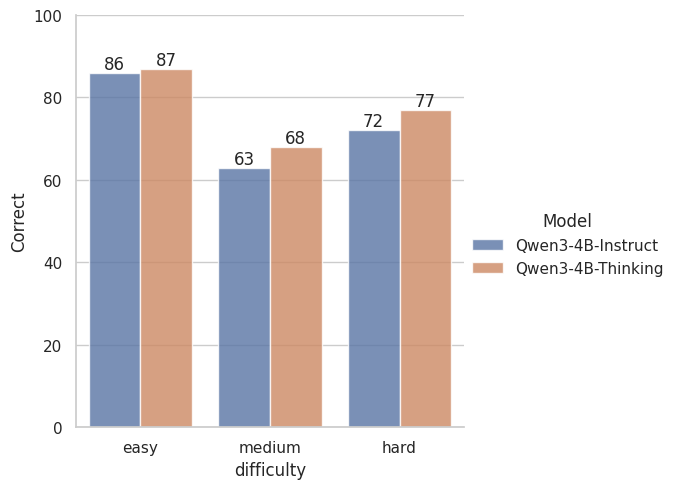

In [40]:

g = sns.catplot(
    formatted,
    x="type", y="Correct", hue="Model",
    kind="bar",
    **style
  )

for container in g.ax.containers:
    g.ax.bar_label(container, fmt="%d")
g.set_xlabels("difficulty")
g.ax.set_ylim((0,100))
g.savefig("mb.pdf", bbox_inches="tight")

In [41]:
def prep_tqa(model_name):
  results = pd.read_csv(
      f"s3://aisa/results/{model_name}/tqa.csv",
      storage_options=storage_options)

  formatted = results.groupby("res").size().reset_index(name=model_name)
  return formatted

In [42]:
merged = pd.merge(prep_tqa(model_name_instruct), prep_tqa(model_name_thinking), on="res")

In [43]:
formatted = merged.melt(id_vars='res', var_name='Model', value_name='Count')
formatted["res"] = formatted["res"].map({
    "A": "best",
    "B": "correct",
    "C": "wrong"
})

formatted["Model"] = formatted["Model"].map({
    "Qwen/Qwen3-4B-Instruct-2507": "Qwen3-4B-Instruct",
    "Qwen/Qwen3-4B-Thinking-2507": "Qwen3-4B-Thinking"
})


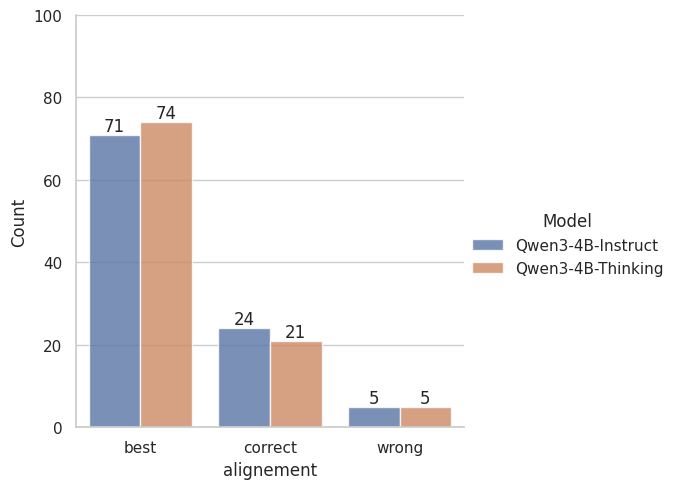

In [44]:
g = sns.catplot(
    formatted,
    x="res",
    y="Count",
    hue="Model",
    kind="bar",
    **style
)
for container in g.ax.containers:
    g.ax.bar_label(container, fmt="%d")

g.set_xlabels("alignement")
g.ax.set_ylim((0,100))
g.savefig("tqa.pdf", bbox_inches="tight")